# Problem C: Surrogate Modeling for Steady-State Heat Conduction in Heterogeneous Materials

Consider the steady-state heat conduction problem in a heterogeneous solid material occupying the unit square domain $\Omega = [0,1]^2$:

$$
\begin{split}
-\nabla\cdot(a(x,y)\nabla u) &= f,\quad (x,y)\in\Omega=[0,1]^2 \\
u &= 0,\quad (x,y)\in\partial\Omega
\end{split} \tag{2}
$$

where $u(x,y)$ denotes the temperature field, $a(x,y) > 0$ denotes the spatially varying thermal conductivity of the material, and the uniform heat source is given by $f = 10$. The zero Dirichlet boundary condition models a configuration in which the boundary of the domain is kept at a fixed reference temperature.

In computational materials science, evaluating the thermal response of a large number of candidate microstructures is a central bottleneck in material screening and design workflows. Although high-fidelity Finite Element Method (FEM) solvers can produce accurate solutions, they are computationally expensive when applied repeatedly to thousands of different conductivity fields $a(x,y)$.

## Task: Learning the Solution Operator $a(x,y) \mapsto u(x,y)$

The goal of this task is to make a fast prediction of the temperature field $u(x,y)$ given $a(x,y)$. To this end, a dataset of input-output pairs $\{a^{(j)}, u^{(j)}\}$ has been pre-computed using a high-precision FEM solver. The conductivity fields $a^{(j)}$ are sampled from a distribution $\mathcal{A}$ over spatially heterogeneous functions, representative of realistic microstructural variability in composite materials. Once trained, the model should accurately predict the temperature field for new, unseen conductivity samples drawn from the same distribution $\mathcal{A}$, at a fraction of the cost of a full FEM solve.

### Goals

- Please select a suitable deep learning method for this task and justify your choice.
- Report your implementation setup, including network architecture, activation function, optimizer (with learning rate), number of epochs, batch size, loss formulation, and any additional techniques used for improvement.
- Compute the $L^2$ relative error on the **test dataset** at each training epoch and plot the `Error vs. Epoch` curve (reporting the final error). The $L^2$ relative error between predictions $\{u^{(j)}_{\text{pred}}\}_{j=1}^{N}$ and ground truth $\{u^{(j)}_{\text{true}}\}_{j=1}^{N}$ is defined as:

$$
\text{error} = \frac{1}{N}\sum_{j=1}^{N}\sqrt{\frac{\sum_i\left|u^{(j)}_{\text{pred}}(x_i)-u^{(j)}_{\text{true}}(x_i)\right|^2}{\sum_i\left|u^{(j)}_{\text{true}}(x_i)\right|^2}}
$$

where $j$ indexes the sample and $i$ indexes the spatial grid point.

- For the **first test instance**, use `matplotlib` to plot the following in separate figures:
  1. The input conductivity field $a(x,y)$
  2. The predicted temperature field $u_{\text{pred}}(x,y)$
  3. The ground truth temperature field $u_{\text{true}}(x,y)$
  4. The pointwise absolute error $|u_{\text{pred}} - u_{\text{true}}|$

### Dataset

The training and test data are provided in `ProblemC_dataset.h5`:

| Key | Shape | Description |
|---|---|---|
| `a_train` | (1000, 128, 128) | Training conductivity fields sampled from $\mathcal{A}$ |
| `u_train` | (1000, 128, 128) | Corresponding FEM-computed temperature fields (training) |
| `a_test` | (200, 128, 128) | Test conductivity fields (for error evaluation only, **do not use for training**) |
| `u_test` | (200, 128, 128) | Corresponding FEM-computed temperature fields (test reference, **do not use for training**) |
| `X` | (128, 128) | $x$-coordinates of the $128\times 128$ regular spatial grid |
| `Y` | (128, 128) | $y$-coordinates of the $128\times 128$ regular spatial grid |

> 📥 Dataset download: [https://www.kaggle.com/datasets/yhzang32/dno4pdes](https://www.kaggle.com/datasets/yhzang32/dno4pdes)

<KeysViewHDF5 ['X', 'Y', 'a_test', 'a_train', 'u_test', 'u_train']>
The shape of X: torch.Size([128, 128]) The shape of Y: torch.Size([128, 128])
The shape of a_train: torch.Size([1000, 128, 128])
The shape of u_train: torch.Size([1000, 128, 128])
The shape of a_test: torch.Size([200, 128, 128])
The shape of u_test: torch.Size([200, 128, 128])


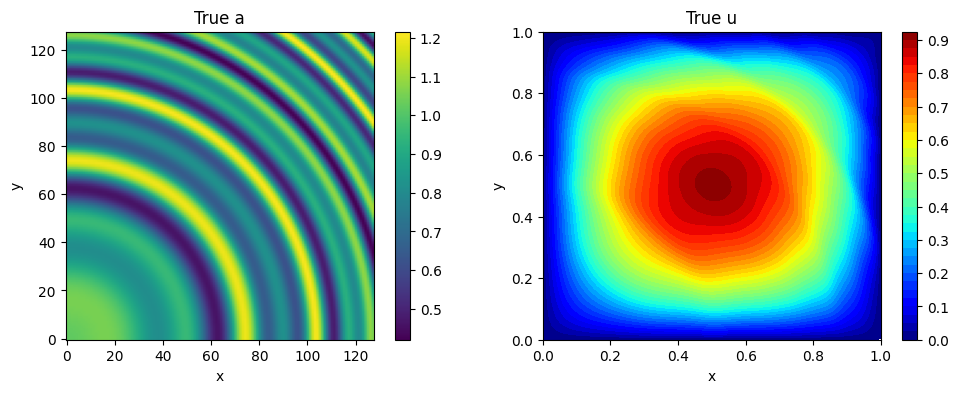

In [1]:
import numpy as np
import h5py
import torch 
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
device = 'cpu'
dtype = torch.float32
######################################
# Load training data
######################################
with h5py.File('ProblemC_dataset.h5', 'r') as data:
    print(data.keys())
    a_train = torch.tensor(np.array(data["a_train"]), dtype=dtype)
    u_train = torch.tensor(np.array(data["u_train"]), dtype=dtype)
    a_test = torch.tensor(np.array(data["a_test"]), dtype=dtype)
    u_test =torch.tensor( np.array(data["u_test"]), dtype=dtype)
    # The coordinates
    X = torch.tensor(np.array(data['X']), dtype=dtype)
    Y = torch.tensor(np.array(data['Y']), dtype=dtype)
print('The shape of X:', X.shape, 'The shape of Y:', Y.shape)
print('The shape of a_train:', a_train.shape)
print('The shape of u_train:', u_train.shape)
print('The shape of a_test:', a_test.shape)
print('The shape of u_test:', u_test.shape)

####### Visualize the training data 
a_show, u_show = a_train[1], u_train[1]
#
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
#
cntr0 = axs.flat[:][0].imshow(a_show, origin='lower')
fig.colorbar(cntr0, ax=axs.flat[:][0])
axs.flat[:][0].set_title('True a')
axs.flat[:][0].set_xlabel('x')
axs.flat[:][0].set_ylabel('y')
#
cntr1 = axs.flat[:][1].contourf(X, Y, u_show, levels=40, cmap='jet')
fig.colorbar(cntr1, ax=axs.flat[:][1])
axs.flat[:][1].set_title('True u')
axs.flat[:][1].set_xlabel('x')
axs.flat[:][1].set_ylabel('y')
#
plt.show()

In [2]:
import torch.nn as nn

class SpectralConv2d(nn.Module):

    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2

        scale = 1.0 / (in_channels * out_channels)
        
        self.weights1 = nn.Parameter(scale * torch.rand(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(scale * torch.rand(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))

    def compl_mul2d(self, input, weights):
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        x_ft = torch.fft.rfft2(x)
        out_ft = torch.zeros(batchsize, self.out_channels, x.size(-2), x.size(-1) // 2 + 1,dtype=torch.cfloat, device=x.device)
        out_ft[:, :, :self.modes1, :self.modes2] = self.compl_mul2d(x_ft[:, :, :self.modes1, :self.modes2], self.weights1)
        out_ft[:, :, -self.modes1:, :self.modes2] = self.compl_mul2d(x_ft[:, :, -self.modes1:, :self.modes2], self.weights2)
        return torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))

class FNO2d(nn.Module):
    def __init__(self, modes1=12, modes2=12, width=32, n_layers=4):
        super().__init__()
        self.fc0 = nn.Linear(3, width)
        self.spectral_convs = nn.ModuleList([SpectralConv2d(width, width, modes1, modes2) for _ in range(n_layers)])
        self.pointwise_convs = nn.ModuleList([nn.Conv2d(width, width, 1) for _ in range(n_layers)])
        self.fc1 = nn.Linear(width, 128)
        self.fc2 = nn.Linear(128, 1)
        self.act = nn.GELU()

    def forward(self, x):
        x = self.fc0(x)
        x = x.permute(0, 3, 1, 2)
        for k, (spec, pw) in enumerate(zip(self.spectral_convs, self.pointwise_convs)):
            x = spec(x) + pw(x)
            if k < len(self.spectral_convs) - 1:
                x = self.act(x)
        x = x.permute(0, 2, 3, 1)
        x = self.act(self.fc1(x))
        x = self.fc2(x)
        return x.squeeze(-1)

In [3]:
torch.manual_seed(0)
np.random.seed(0)
device = 'cuda'

a_mean, a_std = a_train.mean(dim=0), a_train.std(dim=0)

def make_input(a):
    a_norm = (a - a_mean) / (a_std + 1e-8)
    B = a.shape[0]
    grid_x = X.unsqueeze(0).expand(B, -1, -1)
    grid_y = Y.unsqueeze(0).expand(B, -1, -1)
    return torch.stack([a_norm, grid_x, grid_y], dim=-1)

x_train = make_input(a_train)
x_test = make_input(a_test)

def relative_l2(pred, true):
    diff = torch.norm(pred.flatten(1) - true.flatten(1), dim=1)
    ref = torch.norm(true.flatten(1), dim=1)
    return diff / ref

epochs = 100
batch_size = 20

model = FNO2d(modes1=12, modes2=12, width=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
train_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(x_train, u_train), batch_size=batch_size, shuffle=True)

In [4]:
train_losses, test_errors = [], []

for epoch in range(1, epochs + 1):
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = relative_l2(model(xb), yb).mean()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.shape[0]
    scheduler.step()
    train_losses.append(epoch_loss / len(train_loader.dataset))

    model.eval()
    with torch.no_grad():
        errs = [relative_l2(model(x_test[i:i+50].to(device)), u_test[i:i+50].to(device)) for i in range(0, x_test.shape[0], 50)]
        test_errors.append(torch.cat(errs).mean().item())

    if epoch == 1 or epoch % 10 == 0:
        print(f'epoch {epoch:3d}/{epochs} | train loss {train_losses[-1]:.4f} | 'f'test L2 rel. error {test_errors[-1]:.4f}')

epoch   1/100 | train loss 0.3900 | test L2 rel. error 0.0385
epoch  10/100 | train loss 0.0148 | test L2 rel. error 0.0210
epoch  20/100 | train loss 0.0098 | test L2 rel. error 0.0160
epoch  30/100 | train loss 0.0117 | test L2 rel. error 0.0126
epoch  40/100 | train loss 0.0065 | test L2 rel. error 0.0083
epoch  50/100 | train loss 0.0080 | test L2 rel. error 0.0106
epoch  60/100 | train loss 0.0050 | test L2 rel. error 0.0076
epoch  70/100 | train loss 0.0045 | test L2 rel. error 0.0081
epoch  80/100 | train loss 0.0041 | test L2 rel. error 0.0072
epoch  90/100 | train loss 0.0039 | test L2 rel. error 0.0073
epoch 100/100 | train loss 0.0038 | test L2 rel. error 0.0072


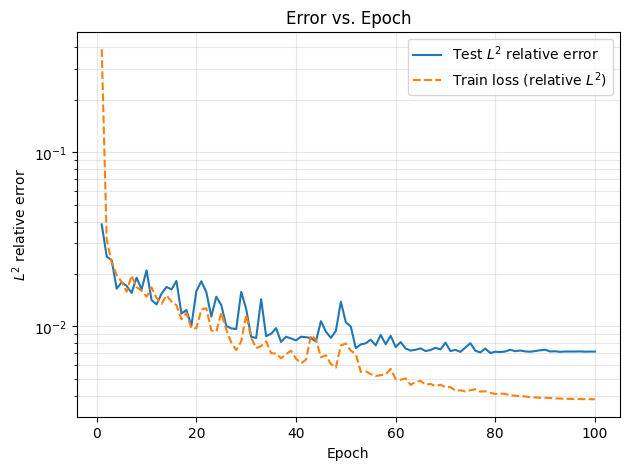

Final test L2 relative error after 100 epochs: 0.0072 (0.72%)


In [ ]:
plt.figure(figsize=(7, 5))
plt.semilogy(range(1, epochs + 1), test_errors, label='Test $L^2$ relative error')
plt.semilogy(range(1, epochs + 1), train_losses, '--', label='Train loss (relative $L^2$)')
plt.xlabel('Epoch')
plt.ylabel('$L^2$ relative error')
plt.title('Error vs. Epoch')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

print(f'Final test L2 relative error after {epochs} epochs: 'f'{test_errors[-1]:.4f} ({test_errors[-1]*100:.2f}%)')

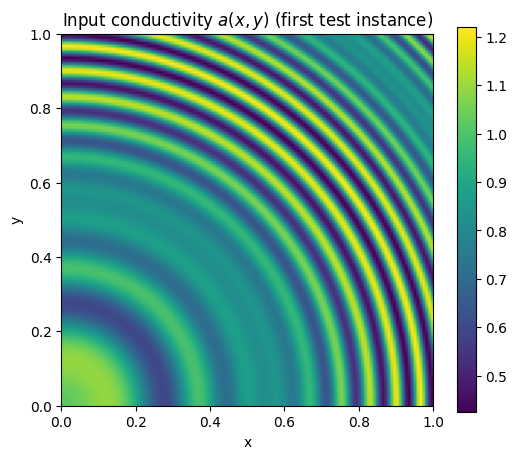

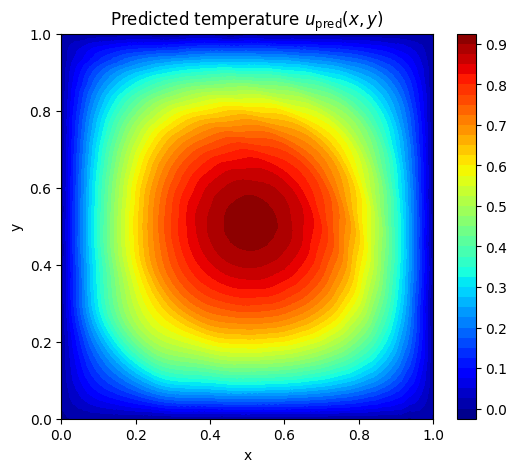

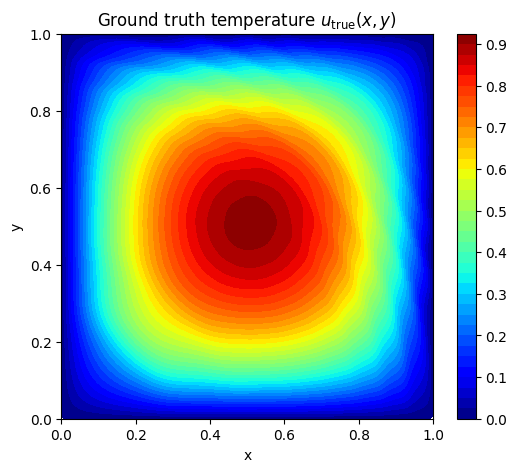

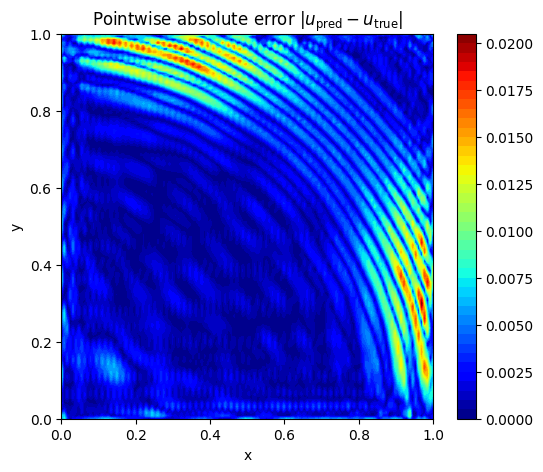

In [6]:
model.eval()
with torch.no_grad():
    u_pred0 = model(x_test[:1].to(device)).cpu()[0]
a0 = a_test[0]
u_true0 = u_test[0]
abs_err0 = (u_pred0 - u_true0).abs()

# Input conductivity field a(x,y)
plt.figure(figsize=(6, 5))
im = plt.imshow(a0, origin='lower', extent=[0, 1, 0, 1])
plt.colorbar(im)
plt.title('Input conductivity $a(x,y)$ (first test instance)')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

# Predicted temperature field
plt.figure(figsize=(6, 5))
cs = plt.contourf(X, Y, u_pred0, levels=40, cmap='jet')
plt.colorbar(cs)
plt.title('Predicted temperature $u_{\\mathrm{pred}}(x,y)$')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

# Ground truth temperature field
plt.figure(figsize=(6, 5))
cs = plt.contourf(X, Y, u_true0, levels=40, cmap='jet')
plt.colorbar(cs)
plt.title('Ground truth temperature $u_{\\mathrm{true}}(x,y)$')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

# Pointwise absolute error
plt.figure(figsize=(6, 5))
cs = plt.contourf(X, Y, abs_err0, levels=40, cmap='jet')
plt.colorbar(cs)
plt.title('Pointwise absolute error $|u_{\\mathrm{pred}} - u_{\\mathrm{true}}|$')
plt.xlabel('x')
plt.ylabel('y')
plt.show()